# Step 1:Importing Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV, cross_val_score


# Load the Dataset

In [13]:
df=pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\streamlit\ML_FinalProj_1\burnout_predictor\Depression&Anxiety in Tech_Dataset.csv")
print("Dataset Loaded")

Dataset Loaded


# Dataset Previewing

In [14]:
print("Dataset Information")
print("-"*20)
df.info()

Dataset Information
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_wee

In [15]:
print("Total Entries: ",df.shape[0])
print("Total Features: ",df.shape[1])

Total Entries:  100000
Total Features:  36


In [16]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


# STEP 3 — Exploratory Data Analysis (EDA)

## Checking Missing Values

In [17]:
print("Finding Missing Values in each Row:")
df.isnull().sum()

Finding Missing Values in each Row:


employee_id                    0
age                            0
gender                         0
country                        0
job_role                       0
seniority_level                0
years_experience               0
years_at_company               0
company_size                   0
industry                       0
work_mode                      0
salary_usd                     0
work_hours_per_week            0
meetings_per_day               0
team_size                      0
sleep_hours_per_night          0
exercise_days_per_week         0
vacation_days_taken            0
therapy_access                 0
uses_therapy                   0
ai_tools_daily                 0
manager_support_score          0
work_life_balance_score        0
job_satisfaction_score         0
social_support_score           0
deadline_pressure_score        0
autonomy_score                 0
stress_score                   0
burnout_score                  0
phq9_score                     0
phq9_categ

## Checking Duplicates

In [18]:
print("Finding Duplicates: ")
df.duplicated().any()

Finding Duplicates: 


np.False_

## Target column Distribution

In [19]:
print("Burnoutlevel Distribution: ")
df["burnout_level"].value_counts()

Burnoutlevel Distribution: 


burnout_level
Severe      28576
Moderate    26255
Low         25807
High        19362
Name: count, dtype: int64

In [20]:

print("Burnout Level % (should be roughly equal for balanced data):")
print((df['burnout_level'].value_counts(normalize=True) * 100).round(2))


Burnout Level % (should be roughly equal for balanced data):
burnout_level
Severe      28.58
Moderate    26.26
Low         25.81
High        19.36
Name: proportion, dtype: float64


In [21]:

print("Average Stress Score by Burnout Level:")
print(df.groupby('burnout_level')['stress_score'].mean().round(2))



Average Stress Score by Burnout Level:
burnout_level
High        7.78
Low         4.65
Moderate    6.53
Severe      9.23
Name: stress_score, dtype: float64


In [22]:

print("Average Sleep Hours by Burnout Level:")
print(df.groupby('burnout_level')['sleep_hours_per_night'].mean().round(2))


Average Sleep Hours by Burnout Level:
burnout_level
High        5.99
Low         6.54
Moderate    6.18
Severe      5.71
Name: sleep_hours_per_night, dtype: float64


In [23]:
print("Average PHQ-9 (Depression) Score by Burnout Level:")
print(df.groupby('burnout_level')['phq9_score'].mean().round(2))



Average PHQ-9 (Depression) Score by Burnout Level:
burnout_level
High         7.16
Low          1.98
Moderate     4.81
Severe      10.90
Name: phq9_score, dtype: float64


## Visualisation

C:\Users\hp\AppData\Local\Temp\ipykernel_5772\3495583009.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ordered.groupby('burnout_level')['phq9_score'].mean()[order].plot(


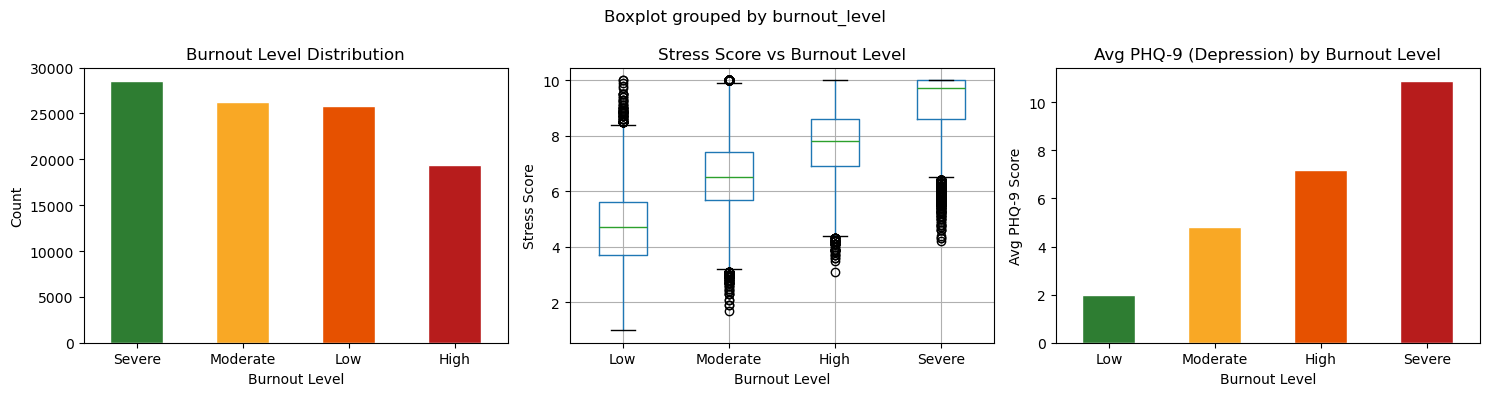

✅ EDA charts saved as eda_charts.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Class distribution
df['burnout_level'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2e7d32','#f9a825','#e65100','#b71c1c'], edgecolor='white')
axes[0].set_title("Burnout Level Distribution")
axes[0].set_xlabel("Burnout Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)


# Chart 2: Stress score by burnout level (box plot)
order = ['Low', 'Moderate', 'High', 'Severe']
df_ordered = df.copy()
df_ordered['burnout_level'] = pd.Categorical(df['burnout_level'], categories=order, ordered=True)
df_ordered.sort_values('burnout_level').boxplot(
    column='stress_score', by='burnout_level', ax=axes[1])
axes[1].set_title("Stress Score vs Burnout Level")
axes[1].set_xlabel("Burnout Level")
axes[1].set_ylabel("Stress Score")


# Chart 3: PHQ-9 score by burnout level
df_ordered.groupby('burnout_level')['phq9_score'].mean()[order].plot(
    kind='bar', ax=axes[2],
    color=['#2e7d32','#f9a825','#e65100','#b71c1c'], edgecolor='white')
axes[2].set_title("Avg PHQ-9 (Depression) by Burnout Level")
axes[2].set_xlabel("Burnout Level")
axes[2].set_ylabel("Avg PHQ-9 Score")
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.savefig("eda_charts.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved as eda_charts.png")



# STEP 4 — Preprocessing (Cleaning the Data)

#### Intially we will drop the unwanted columns from a dataset
##### - **employee_id**  → just a row number, carries no information
##### - **burnout_score** → this is a NUMBER version of burnout_level
#####                 (if we keep it, model gets 100% — that's cheating! called DATA LEAKAGE)
##### - **phq9_category** → this is just a text label of phq9_score (already have the number)
##### - **gad7_category** → same reason as above


In [25]:
df=df.drop(columns=['employee_id', 'burnout_score', 'phq9_category', 'gad7_category'])
print("Successfully removed the UnWanted Columns")

Successfully removed the UnWanted Columns


In [26]:
#Let we check the features for clarification
print("Number of Features: ",df.shape[1])


Number of Features:  32



#### ── Convert TEXT columns to NUMBERS ──────────────────────
##### ML models cannot understand "Male", "Female" etc.
##### LabelEncoder converts: "Female"→0, "Male"→1, "Non-binary"→2


In [27]:
#Let we observe all datatypes of each feature
df.dtypes

age                              int64
gender                          object
country                         object
job_role                        object
seniority_level                 object
years_experience                 int64
years_at_company               float64
company_size                    object
industry                        object
work_mode                       object
salary_usd                       int64
work_hours_per_week              int64
meetings_per_day               float64
team_size                        int64
sleep_hours_per_night          float64
exercise_days_per_week           int64
vacation_days_taken              int64
therapy_access                   int64
uses_therapy                     int64
ai_tools_daily                   int64
manager_support_score          float64
work_life_balance_score        float64
job_satisfaction_score         float64
social_support_score           float64
deadline_pressure_score        float64
autonomy_score           

In [28]:

# Find all text columns (excluding the target)
TARGET= 'burnout_level'
text_columns = [col for col in df.select_dtypes(include=['object', 'string']).columns
                if col != TARGET]

print(f"Text columns to encode: {text_columns}")


Text columns to encode: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode']


In [29]:
label_encoders = {}
for col in text_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"   Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")



   Encoded 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Non-binary': np.int64(2), 'Prefer not to say': np.int64(3)}
   Encoded 'country': {'Australia': np.int64(0), 'Brazil': np.int64(1), 'Canada': np.int64(2), 'France': np.int64(3), 'Germany': np.int64(4), 'India': np.int64(5), 'Netherlands': np.int64(6), 'Singapore': np.int64(7), 'UK': np.int64(8), 'USA': np.int64(9)}
   Encoded 'job_role': {'Backend Developer': np.int64(0), 'Cloud Engineer': np.int64(1), 'Cybersecurity Engineer': np.int64(2), 'Data Analyst': np.int64(3), 'Data Scientist': np.int64(4), 'DevOps Engineer': np.int64(5), 'Frontend Developer': np.int64(6), 'Full Stack Developer': np.int64(7), 'ML Engineer': np.int64(8), 'Product Manager': np.int64(9), 'QA Engineer': np.int64(10), 'Software Engineer': np.int64(11)}
   Encoded 'seniority_level': {'Junior': np.int64(0), 'Lead': np.int64(1), 'Manager': np.int64(2), 'Mid': np.int64(3), 'Principal': np.int64(4), 'Senior': np.int64(5)}
   Encoded 'company_size': {'Ent

In [30]:
# Convert mappings into DataFrame
mapping_df = pd.DataFrame([
    {"Column": col, "Original": cls, "Encoded": enc}
    for col, le in label_encoders.items()
    for cls, enc in zip(le.classes_, le.transform(le.classes_))
])

print(mapping_df)


             Column                Original  Encoded
0            gender                  Female        0
1            gender                    Male        1
2            gender              Non-binary        2
3            gender       Prefer not to say        3
4           country               Australia        0
5           country                  Brazil        1
6           country                  Canada        2
7           country                  France        3
8           country                 Germany        4
9           country                   India        5
10          country             Netherlands        6
11          country               Singapore        7
12          country                      UK        8
13          country                     USA        9
14         job_role       Backend Developer        0
15         job_role          Cloud Engineer        1
16         job_role  Cybersecurity Engineer        2
17         job_role            Data Analyst   

In [31]:
label_encoders = {}

for col in text_columns:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

    mapping_df = pd.DataFrame({
        "Original_Value": le.classes_,
        "Encoded_Value": le.transform(le.classes_)
    })

    print(f"\nEncoding for '{col}':")
    print(mapping_df)


Encoding for 'gender':
  Original_Value  Encoded_Value
0              0              0
1              1              1
2              2              2
3              3              3

Encoding for 'country':
  Original_Value  Encoded_Value
0              0              0
1              1              1
2              2              2
3              3              3
4              4              4
5              5              5
6              6              6
7              7              7
8              8              8
9              9              9

Encoding for 'job_role':
   Original_Value  Encoded_Value
0               0              0
1               1              1
2              10              2
3              11              3
4               2              4
5               3              5
6               4              6
7               5              7
8               6              8
9               7              9
10              8             10
11              9

In [32]:
# ── Encode the target column ──────────────────────────────
le_target = LabelEncoder()
df[TARGET] = le_target.fit_transform(df[TARGET])
label_encoders['target'] = le_target
print(f"\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")


Target encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}


In [33]:
target_mapping = pd.DataFrame({
    'Original_Label': le_target.classes_,
    'Encoded_Value': le_target.transform(le_target.classes_)
})

target_mapping

,Original_Label,Encoded_Value
0,High,0
1,Low,1
2,Moderate,2
3,Severe,3


In [34]:
# ── Separate X (inputs) and y (output) ───────────────────
X = df.drop(columns=[TARGET])   # all columns except burnout_level
y = df[TARGET]                  


In [35]:
print(f"\n✅ Preprocessing done!")
print(f"X shape (features): {X.shape}")   
print(f"y shape (target)  : {y.shape}")   
print(f"Feature names: {list(X.columns)}")



✅ Preprocessing done!
X shape (features): (100000, 31)
y shape (target)  : (100000,)
Feature names: ['age', 'gender', 'country', 'job_role', 'seniority_level', 'years_experience', 'years_at_company', 'company_size', 'industry', 'work_mode', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score', 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score', 'phq9_score', 'gad7_score', 'seeks_mental_health_support', 'job_change_intention']


# STEP 5 — Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Data split done!")
print(f"   Training samples : {X_train.shape}  (80%)")
print(f"   Testing samples  : {X_test.shape}  (20%)")
print(f"   Training samples : {y_train.shape}  (80%)")
print(f"   Testing samples  : {y_test.shape}  (20%)")


Data split done!
   Training samples : (80000, 31)  (80%)
   Testing samples  : (20000, 31)  (20%)
   Training samples : (80000,)  (80%)
   Testing samples  : (20000,)  (20%)


# STEP 6 — Feature Scaling

In [37]:
scaler = StandardScaler()
X_train_trans = scaler.fit_transform(X_train)
X_test_trans  = scaler.transform(X_test)


# STEP 7 — Train the ML Models

## MODEL 1: K-Nearest Neighbors

In [38]:
# Parameters to test
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [39]:
# Create GridSearchCV object
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [40]:
# Train
knn_grid.fit(X_train_trans, y_train)



,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [41]:
# Best model
best_knn = knn_grid.best_estimator_

# Predictions
y_pred_knn = best_knn.predict(X_test_trans)
print("✅ KNN Hyperparameter Tuning Completed")
print("Best Parameters:", knn_grid.best_params_)
print("Best Cross Validation Score:", knn_grid.best_score_)

✅ KNN Hyperparameter Tuning Completed
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best Cross Validation Score: 0.6376250000000001


## MODEL 2: Gaussian Naive Bayes

In [42]:
nb = GaussianNB()
# 5-Fold Cross Validation
cv_scores_nb = cross_val_score(nb,X_train_trans,y_train,cv=5,scoring='accuracy')


## MODEL 2: Gaussian Naive Bayes


In [43]:
nb = GaussianNB()

In [44]:
# 5-Fold Cross Validation
cv_scores_nb = cross_val_score(
    nb,
    X_train_trans,
    y_train,
    cv=5,
    scoring='accuracy'
)


In [45]:
# Train final model
nb.fit(X_train_trans, y_train)

,priors,None
,var_smoothing,1e-09


In [46]:
# Prediction
y_pred_nb = nb.predict(X_test_trans)


In [47]:

print("✅ Naive Bayes Training Completed")
print("Cross Validation Scores:", cv_scores_nb)
print("Average CV Accuracy:", cv_scores_nb.mean())

✅ Naive Bayes Training Completed
Cross Validation Scores: [0.687625  0.6949375 0.6875625 0.6893125 0.6908125]
Average CV Accuracy: 0.6900499999999999


## MODEL 3: Decision Tree (Hyperparameter Tuning)

In [48]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [49]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [50]:
# Train
dt_grid.fit(X_train_trans, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [51]:
# Best model
best_dt = dt_grid.best_estimator_


In [52]:
# Prediction
y_pred_dt = best_dt.predict(X_test_trans)


In [53]:
print("Decision Tree Hyperparameter Tuning Completed")
print("Best Parameters:", dt_grid.best_params_)
print("Best Cross Validation Score:", dt_grid.best_score_)

Decision Tree Hyperparameter Tuning Completed
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross Validation Score: 0.672375


# STEP 8 — Evaluate the Models

In [54]:
CLASS_NAMES = le_target.classes_
results = {}

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"--- {name} ---")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results[name] = {"model": None, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    return acc, prec, rec, f1

In [56]:
#Getting predictions for each model
y_pred_knn = best_knn.predict(X_test_trans)
y_pred_nb  = nb.predict(X_test_trans)
y_pred_dt  = best_dt.predict(X_test_trans)

--- KNN ---
Accuracy  : 64.05%
Precision : 0.6263
Recall    : 0.6404
F1 Score  : 0.6309
              precision    recall  f1-score   support

        High       0.42      0.30      0.35      3873
         Low       0.73      0.80      0.77      5161
    Moderate       0.51      0.54      0.53      5251
      Severe       0.77      0.82      0.79      5715

    accuracy                           0.64     20000
   macro avg       0.61      0.62      0.61     20000
weighted avg       0.63      0.64      0.63     20000



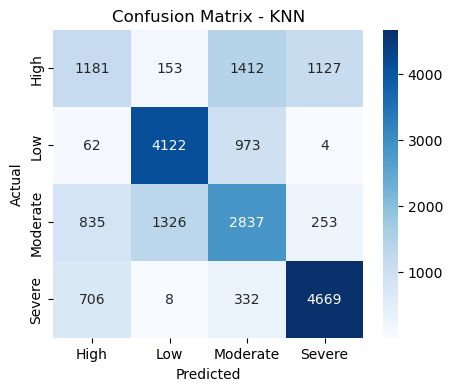

--- Naive Bayes ---
Accuracy  : 69.41%
Precision : 0.6928
Recall    : 0.6940
F1 Score  : 0.6932
              precision    recall  f1-score   support

        High       0.49      0.45      0.47      3873
         Low       0.81      0.80      0.80      5161
    Moderate       0.59      0.62      0.60      5251
      Severe       0.82      0.83      0.83      5715

    accuracy                           0.69     20000
   macro avg       0.68      0.68      0.68     20000
weighted avg       0.69      0.69      0.69     20000



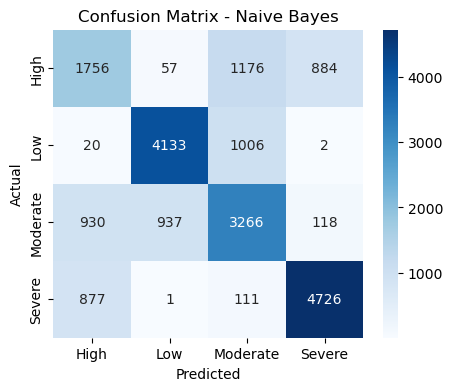

--- Decision Tree ---
Accuracy  : 67.03%
Precision : 0.6718
Recall    : 0.6703
F1 Score  : 0.6707
              precision    recall  f1-score   support

        High       0.45      0.43      0.44      3873
         Low       0.80      0.77      0.79      5161
    Moderate       0.56      0.60      0.58      5251
      Severe       0.81      0.81      0.81      5715

    accuracy                           0.67     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.67      0.67      0.67     20000



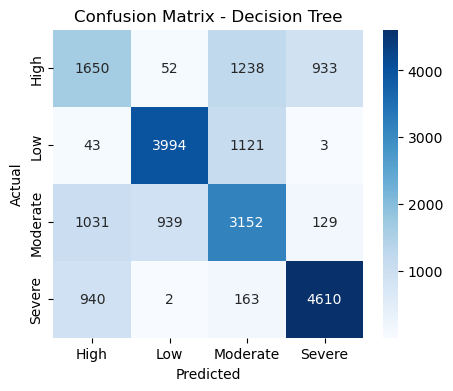

(0.6703, 0.6718490963898923, 0.6703, 0.6707192580279454)

In [57]:
#calling evaluate model for each
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Decision Tree", y_test, y_pred_dt)

In [58]:
# Store the actual fitted model objects in results
results["KNN"]["model"] = best_knn
results["Naive Bayes"]["model"] = nb
results["Decision Tree"]["model"] = best_dt

In [59]:
comparison_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]]
comparison_df

,accuracy,precision,recall,f1
KNN,0.64045,0.626312,0.64045,0.630854
Naive Bayes,0.69405,0.69282,0.69405,0.693165
Decision Tree,0.6703,0.671849,0.6703,0.670719


In [ ]:
#Automatically pick the best model
#Instead of hardcoding best_model = nb, let the code decide based on F1 score:

best_model_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_model_name]["model"]

print(f"Best Model: {best_model_name}")
print(f"F1 Score: {results[best_model_name]['f1']:.4f}")

Best Model: Naive Bayes
F1 Score: 0.6932


In [61]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/best_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(label_encoders, "model/label_encoders.pkl")
joblib.dump(list(X.columns), "model/feature_names.pkl")

print("Model saved to model/ folder")
print("Files: best_model.pkl, scaler.pkl, label_encoders.pkl, feature_names.pkl")

Model saved to model/ folder
Files: best_model.pkl, scaler.pkl, label_encoders.pkl, feature_names.pkl
